# Environment and Runtime Validation

This notebook validates the Python interpreter, project kernel, operating system, and repository paths before running the causal decision experiments.

In [1]:
import platform
import sys

print("Python executable:", sys.executable)
print("Python version:", platform.python_version())
print("Operating system:", platform.platform())

Python executable: d:\article28-unet-projects\predictive-vs-causal-decision-lab\.venv\Scripts\python.exe
Python version: 3.11.9
Operating system: Windows-10-10.0.26100-SP0


In [2]:
from pathlib import Path


def find_project_root(start: Path, marker: str = "README.md") -> Path:
    """Find the project root by searching for a marker file."""
    current = start.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / marker).exists():
            return candidate

    raise FileNotFoundError(f"Missing project marker: {marker}")


PROJECT_ROOT = find_project_root(Path.cwd())
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
TABLES_DIR = PROJECT_ROOT / "reports" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figures directory:", FIGURES_DIR)
print("Tables directory:", TABLES_DIR)

Project root: D:\article28-unet-projects\predictive-vs-causal-decision-lab
Figures directory: D:\article28-unet-projects\predictive-vs-causal-decision-lab\reports\figures
Tables directory: D:\article28-unet-projects\predictive-vs-causal-decision-lab\reports\tables


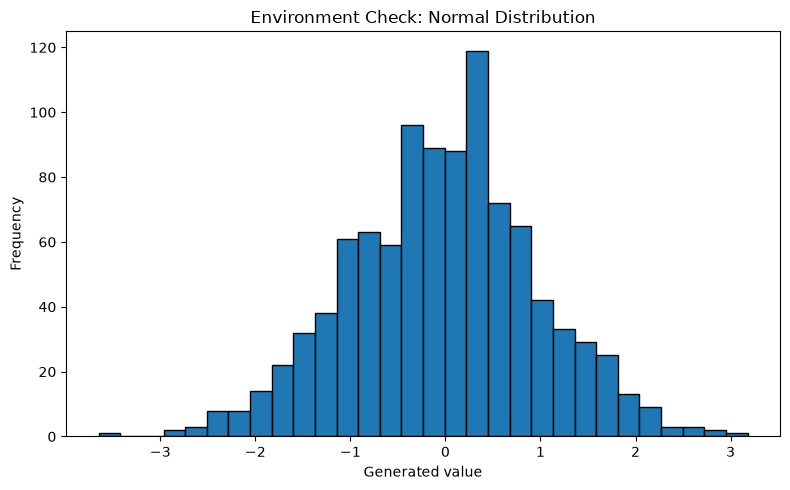

Random seed: 42
Figure saved to: D:\article28-unet-projects\predictive-vs-causal-decision-lab\reports\figures\environment_check_distribution.png
Figure exists: True


In [3]:
import random

import matplotlib.pyplot as plt
import numpy as np


RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

sample = rng.normal(size=1000)

plt.figure(figsize=(8, 5))
plt.hist(sample, bins=30, edgecolor="black")
plt.title("Environment Check: Normal Distribution")
plt.xlabel("Generated value")
plt.ylabel("Frequency")
plt.tight_layout()

output_path = FIGURES_DIR / "environment_check_distribution.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Random seed:", RANDOM_SEED)
print("Figure saved to:", output_path)
print("Figure exists:", output_path.exists())